# **K-Prototypes Clustering Workbook**

This is a K-means prototyping project using mental health data of young adults. It aims to find groups of people that could be targeted by policy.

### **Importing Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

c:\Users\heppe\OneDrive\Documents\Python\K-means\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Setting Options**

In [42]:
# Ensure that all columns are displayed when printing a DataFrame
pd.set_option('display.max_columns', None)

### **Retrieving Data from Kaggle**
https://www.kaggle.com/datasets/uom190346a/mental-health-research-dataset/data

In [6]:
# set path
path = kagglehub.dataset_download("uom190346a/mental-health-research-dataset")
# print out the path of downloaded files
print(path)

100%|██████████| 13.8k/13.8k [00:00<00:00, 1.88MB/s]

Extracting files...
C:\Users\heppe\.cache\kagglehub\datasets\uom190346a\mental-health-research-dataset\versions\1


You will need to retrieve the csv file from the stated path if you want to re-create this method. Otherwise I have uploaded the csv to this repository and will be accessing it from there for the rest of this project

### **Data Loading and Familiarisation**

In [4]:
# read csv
mh = pd.read_csv("Mental_Health_and_Lifestyle_Research.csv")

In [8]:
# head
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Mental_Health_Status,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Substance_Use,Has_Close_Friends,Physical_Health_Condition
0,1,25,Male,7,7,13,9,Mild Anxiety,Low,3,Excellent,8.8,NaN,True,NaN
1,2,34,Female,7,4,46,9,Depression,Moderate,5,Fair,5.1,Alcohol,True,Hypertension
2,3,31,Female,5,6,34,8,NaN,Moderate,4,Fair,6.6,Smoking,True,Obesity
3,4,29,Female,6,7,30,11,Depression,Moderate,2,Good,7.6,Alcohol,True,NaN
4,5,22,Female,7,5,10,7,NaN,Moderate,4,Very Good,6.5,Alcohol,True,Obesity


In [11]:
# information about data types and NAs
mh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   str    
 3   Hours_of_Sleep             1000 non-null   int64  
 4   Stress_Level               1000 non-null   int64  
 5   Physical_Activity          1000 non-null   int64  
 6   Work_Hours_per_Day         1000 non-null   int64  
 7   Mental_Health_Status       358 non-null    str    
 8   Social_Interaction_Freq    1000 non-null   str    
 9   Overall_Wellbeing_Score    1000 non-null   int64  
 10  Diet_Quality               1000 non-null   str    
 11  Screen_Time_per_Day        1000 non-null   float64
 12  Substance_Use              621 non-null    str    
 13  Has_Close_Friends          1000 non-null   bool   
 14  Phys

In [12]:
# look for data ranges
mh.describe()

,Person_ID,Age,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Overall_Wellbeing_Score,Screen_Time_per_Day
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,27.076000,6.950000,5.46900,28.954000,7.994000,4.094000,7.088500
std,288.819436,4.578995,1.127285,2.03892,18.024671,1.412076,2.131128,1.984433
min,1.000000,20.000000,5.000000,1.00000,0.000000,5.000000,1.000000,1.000000
25%,250.750000,23.000000,6.000000,4.00000,15.000000,7.000000,2.000000,5.800000
50%,500.500000,27.000000,7.000000,5.00000,29.000000,8.000000,4.000000,7.100000
75%,750.250000,31.000000,8.000000,7.00000,41.000000,9.000000,6.000000,8.400000
max,1000.000000,35.000000,9.000000,10.00000,93.000000,11.000000,10.000000,12.000000


### **Data Cleaning**
There are a lot of `NaN` entries in some of the categorical columns:
- `Mental_Health_Status`
- `Substance_Use`
- `Physical_Health_Status`

Looking at the [Kaggle documentation](https://www.kaggle.com/datasets/uom190346a/mental-health-research-dataset/data), this would appear to be pandas interpreting `"None"` as `NaN` - going to replace `NaN` with a string.

In [5]:
# replace NaN
mh.fillna("None", inplace=True)

# check it worked
mh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   str    
 3   Hours_of_Sleep             1000 non-null   int64  
 4   Stress_Level               1000 non-null   int64  
 5   Physical_Activity          1000 non-null   int64  
 6   Work_Hours_per_Day         1000 non-null   int64  
 7   Mental_Health_Status       1000 non-null   str    
 8   Social_Interaction_Freq    1000 non-null   str    
 9   Overall_Wellbeing_Score    1000 non-null   int64  
 10  Diet_Quality               1000 non-null   str    
 11  Screen_Time_per_Day        1000 non-null   float64
 12  Substance_Use              1000 non-null   str    
 13  Has_Close_Friends          1000 non-null   bool   
 14  Phys

As per the `describe()` output, all of the continuous variables appear to have plausible ranges

### **Pre-Processing**

One-Hot Encoding categorical variables

In [6]:
# initialise one hot encoder with sparse output and pandas output
encoder = OneHotEncoder(sparse_output=False)
encoder.set_output(transform="pandas")
encoder_cols = ["Mental_Health_Status", "Substance_Use", "Physical_Health_Condition"]

# fit and transform relevant columns
encoded_data = encoder.fit_transform(mh[encoder_cols])
mh[encoded_data.columns] = encoded_data

# drop original columns
mh.drop(columns=encoder_cols, inplace=True)
# also drop None columns
mh.drop(columns=["Mental_Health_Status_None", "Substance_Use_None", "Physical_Health_Condition_None"], inplace=True)
# drop person ID
mh.drop(columns=["Person_ID"], inplace=True)

# not necessary to have 2 columns for Gender and Has_Close_Friends - just apply lambda function
mh["Gender"] = mh["Gender"].apply(lambda x: 1 if x == "Male" else 0)
mh["Has_Close_Friends"] = mh["Has_Close_Friends"].apply(lambda x: 1 if x else 0)

# checking it worked
mh.head()

,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,...,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,25,1,7,7,13,9,Low,3,Excellent,8.8,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34,0,7,4,46,9,Moderate,5,Fair,5.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,31,0,5,6,34,8,Moderate,4,Fair,6.6,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,29,0,6,7,30,11,Moderate,2,Good,7.6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22,0,7,5,10,7,Moderate,4,Very Good,6.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_None,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_None,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_None,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,1,25,1,7,7,13,9,Low,3,Excellent,8.8,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,34,0,7,4,46,9,Moderate,5,Fair,5.1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,31,0,5,6,34,8,Moderate,4,Fair,6.6,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,29,0,6,7,30,11,Moderate,2,Good,7.6,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,22,0,7,5,10,7,Moderate,4,Very Good,6.5,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Some columns are ordinal - going to turn them into numbers (`Social_Interaction_Freq` and `Diet_Quality`)

In [49]:
# identify levels
print(mh["Social_Interaction_Freq"].value_counts())
print(mh["Diet_Quality"].value_counts())

Social_Interaction_Freq
Moderate    506
Low         311
High        183
Name: count, dtype: int64
Diet_Quality
Good         405
Fair         243
Very Good    218
Poor          69
Excellent     65
Name: count, dtype: int64


In [7]:
# create dictionaries to map the levels to numerical values
SI_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

DQ_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Excellent": 4
}

mh["Social_Interaction_Freq"] = mh["Social_Interaction_Freq"].map(SI_map)
mh["Diet_Quality"] = mh["Diet_Quality"].map(DQ_map)

Scaling continuous variables

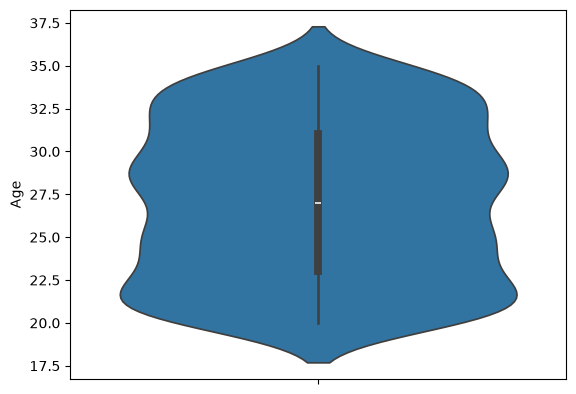

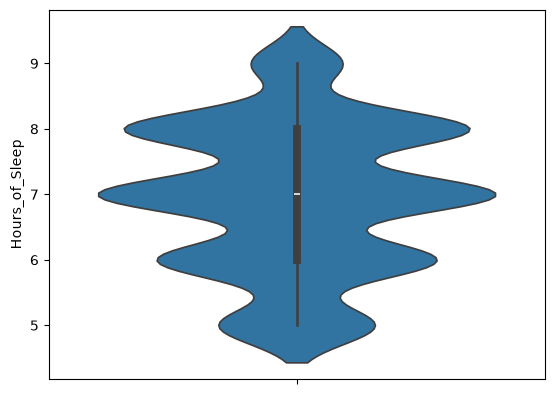

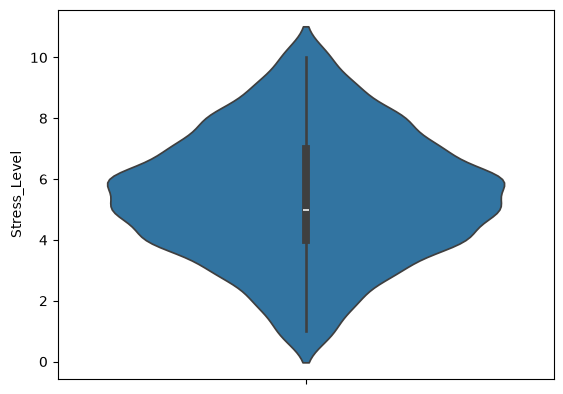

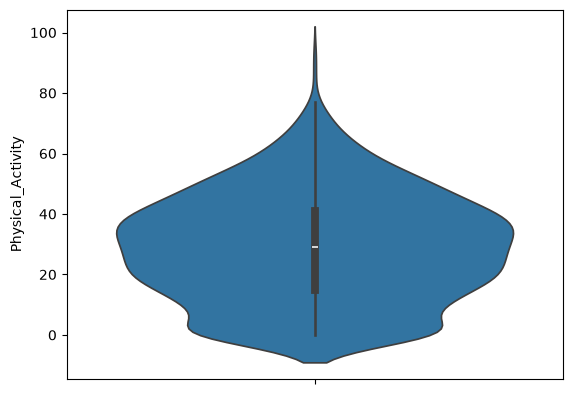

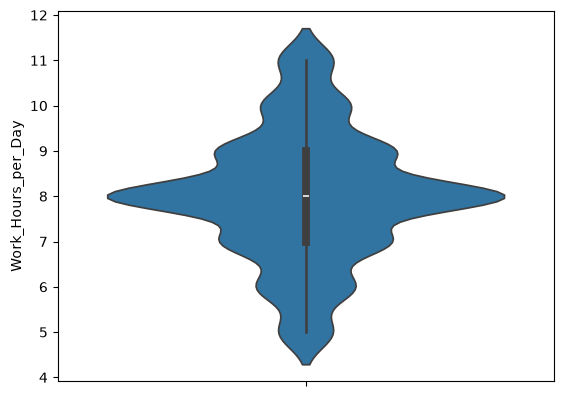

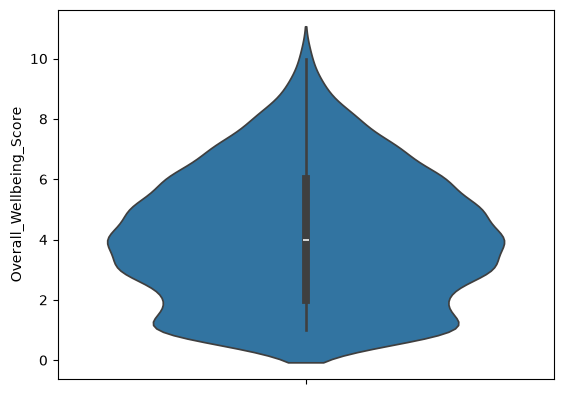

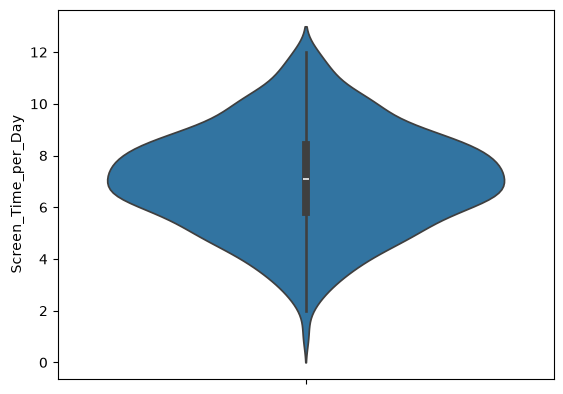

In [9]:
## selecting what kind of scaler to use (ie. how bad are the outliers?) ##

# defining continuous columns
continuous_cols = ["Age", "Hours_of_Sleep", "Stress_Level", "Physical_Activity","Work_Hours_per_Day",
                    "Overall_Wellbeing_Score", "Screen_Time_per_Day"]

for col in continuous_cols:
    sns.violinplot(y=mh[col])
    plt.show()

In [10]:
# Physical activity and wellbeing score are skewed - Robust Scaler
# Everything else looks normally distributed - Standard Scaler
robust_cols = ["Physical_Activity", "Overall_Wellbeing_Score"]
standard_cols = [col for col in continuous_cols if col not in robust_cols]

standard_scaler = StandardScaler()
standard_scaler.fit(mh[standard_cols])
standard_transformed = standard_scaler.transform(mh[standard_cols])

for i, col in enumerate(standard_cols):
    mh[col] = standard_transformed[:, i]

robust_scaler = RobustScaler()
robust_scaler.fit(mh[robust_cols])
robust_transformed = robust_scaler.transform(mh[robust_cols])

for i, col in enumerate(robust_cols):
    mh[col] = robust_transformed[:, i]

In [ ]:
# checking it worked
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_None,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_None,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_None,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,1,-0.453601,1,0.044377,0.751263,-0.615385,0.712783,0,-0.25,4,0.862894,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1.512879,0,0.044377,-0.720840,0.653846,0.712783,1,0.25,1,-1.002551,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,0.857385,0,-1.730686,0.260562,0.192308,0.004251,1,0.00,1,-0.246289,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,0.420390,0,-0.843155,0.751263,0.038462,2.129846,1,-0.50,2,0.257885,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,-1.109095,0,0.044377,-0.230139,-0.730769,-0.704280,1,0.00,3,-0.296707,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### **Analysis**

Need to get the position of the categorical columns

In [ ]:
# get list of the columns
mh.columns

Index(['Age', 'Gender', 'Hours_of_Sleep', 'Stress_Level', 'Physical_Activity',
       'Work_Hours_per_Day', 'Social_Interaction_Freq',
       'Overall_Wellbeing_Score', 'Diet_Quality', 'Screen_Time_per_Day',
       'Has_Close_Friends', 'Mental_Health_Status_Depression',
       'Mental_Health_Status_Mild Anxiety',
       'Mental_Health_Status_Moderate Anxiety',
       'Mental_Health_Status_Severe Anxiety', 'Substance_Use_Alcohol',
       'Substance_Use_Both', 'Substance_Use_Smoking',
       'Physical_Health_Condition_Diabetes',
       'Physical_Health_Condition_Hypertension',
       'Physical_Health_Condition_Obesity',
       'Physical_Health_Condition_Other Chronic Illness'],
      dtype='str')

In [ ]:
# get number of columns - after about half way, it'll be all categorical
len(mh.columns)

22

In [21]:
cat_cols = [1] + list(range(10, 22))
cat_cols
mh.iloc[:, cat_cols]

,Gender,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
997,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
998,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


Convert data frame to matrix

In [22]:
mh_matrix = mh.to_numpy()

Finding the optimal K (`Kprototypes` objects do not have a silhouette score attribute, therefore using elbow method)

In [23]:
%%time
cost = []

for cluster in range(1, 21):
    kproto = KPrototypes(n_jobs = -1,n_clusters=cluster, init='Huang', random_state = 0)
    kproto.fit_predict(mh_matrix, categorical=cat_cols)
    cost.append(kproto.cost_)

CPU times: total: 1 s
Wall time: 48.6 s


[Text(0.5, 0, 'Number of Clusters'), Text(0, 0.5, 'Cost')]

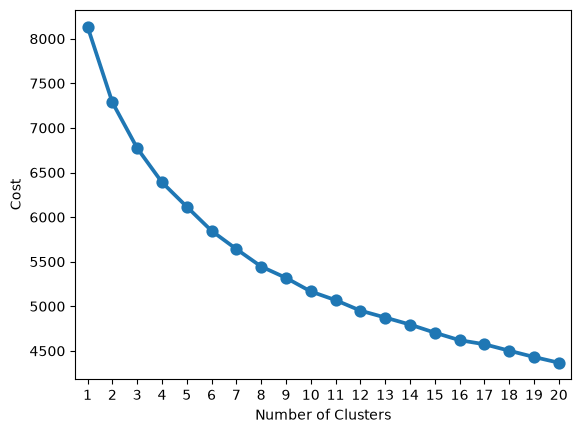

In [24]:
sns.pointplot(x=range(1, 21), y=cost).set(xlabel = "Number of Clusters", ylabel = "Cost")

There is no obvious elbow in the cost curve - need to compute silhouette scores.

In [18]:
# Define a function to calculate a distance matrix for the mixed data types
def Mix_Dis_Mat(Num, Cat, gamma):
    """
    A function to calculate a distance matrix for mixed data types (numerical and categorical) for a KPrototypes object.

    Args:
        Num (pandas DataFrame): A DataFrame containing numerical features.
        Cat (pandas DataFrame): A DataFrame containing categorical features.
        gamma (float): A weight for the categorical distance from the .gamma property of a KPrototypes object.

    Returns:
        numpy.ndarray: A distance matrix for the mixed data types.
    """

    # Calculate the numerical distance matrix using Euclidean distance
    num_dis = squareform(pdist(Num, metric='euclidean'))**2

    # Calculate the categorical distance matrix using Hamming distance
    cat_dis = squareform(pdist(Cat, metric='hamming')) * Cat.shape[1]

    # Combine the numerical and categorical distance matrices with the specified weight for categorical distance
    return num_dis + gamma * cat_dis

# set the data frames to use later
num_data = mh[continuous_cols]
cat_data = mh.iloc[:,cat_cols]

In [25]:
%%time
# Now going to re-run the k-means calculating silhouette scores for each number of clusters
# It looked like the elbow was before 10, so will just do 2-10 clusters

scores = []
for cluster in range(2, 11):
    kproto = KPrototypes(n_jobs = -1,n_clusters=cluster, init='Huang', random_state = 0)
    labels = kproto.fit_predict(mh_matrix, categorical=cat_cols)

    dis_mat = Mix_Dis_Mat(num_data, cat_data, kproto.gamma)
    score = silhouette_score(dis_mat, labels, metric='precomputed')
    scores.append(score)

CPU times: total: 828 ms
Wall time: 20.6 s


[Text(0.5, 0, 'Number of Clusters'), Text(0, 0.5, 'Silhouette Score')]

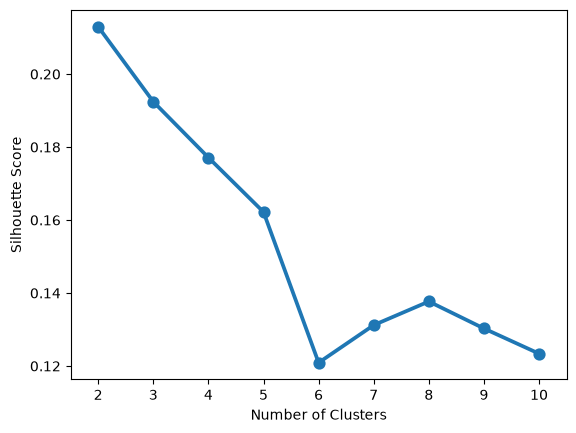

In [26]:
sns.pointplot(x=range(2, 11), y=scores).set(xlabel = "Number of Clusters", ylabel = "Silhouette Score")

This is slightly odd - going to rerun with 3 different random states

In [27]:
%%time

rand42 = []
for cluster in range(2, 11):
    kproto = KPrototypes(n_jobs = -1,n_clusters=cluster, init='Huang', random_state = 42)
    labels = kproto.fit_predict(mh_matrix, categorical=cat_cols)

    dis_mat = Mix_Dis_Mat(num_data, cat_data, kproto.gamma)
    score = silhouette_score(dis_mat, labels, metric='precomputed')
    rand42.append(score)

rand100 = []
for cluster in range(2, 11):
    kproto = KPrototypes(n_jobs = -1,n_clusters=cluster, init='Huang', random_state = 100)
    labels = kproto.fit_predict(mh_matrix, categorical=cat_cols)

    dis_mat = Mix_Dis_Mat(num_data, cat_data, kproto.gamma)
    score = silhouette_score(dis_mat, labels, metric='precomputed')
    rand100.append(score)

rand250 = []
for cluster in range(2, 11):
    kproto = KPrototypes(n_jobs = -1,n_clusters=cluster, init='Huang', random_state = 250)
    labels = kproto.fit_predict(mh_matrix, categorical=cat_cols)

    dis_mat = Mix_Dis_Mat(num_data, cat_data, kproto.gamma)
    score = silhouette_score(dis_mat, labels, metric='precomputed')
    rand250.append(score)

CPU times: total: 2.84 s
Wall time: 1min 8s


<Axes: >

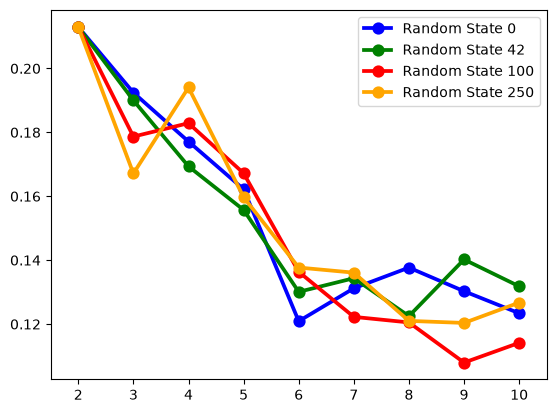

In [28]:
sns.pointplot(x=range(2, 11), y=scores, color='blue', label='Random State 0')
sns.pointplot(x=range(2, 11), y=rand42, color='green', label='Random State 42')
sns.pointplot(x=range(2, 11), y=rand100, color='red', label='Random State 100')
sns.pointplot(x=range(2, 11), y=rand250, color='orange', label='Random State 250')

### **Evaluation**

The lack of a finding with the silhouette scores would suggest that the groups are not particularly clustered. This would be expected of human data. Given this, I am going to say that there are 6 clusters. This is where groups start to be less different from one another.

Firstly, we need to find out which cluster each person belonged to.

In [120]:
%%time
# fit 6 cluster model
final_proto = KPrototypes(n_jobs = -1,n_clusters=6, init='Huang', random_state = 0)
labels = final_proto.fit_predict(mh_matrix, categorical=cat_cols)

CPU times: total: 46.9 ms
Wall time: 2.68 s


In [131]:
# get the original data frame
original = pd.read_csv("Mental_Health_and_Lifestyle_Research.csv")
original.fillna("None", inplace=True)
original.drop("Person_ID", axis=1, inplace=True)

original["Social_Interaction_Freq"] = original["Social_Interaction_Freq"].map(SI_map)
original["Diet_Quality"] = original["Diet_Quality"].map(DQ_map)

# Now add this to the original data frame
original["Cluster"] = labels
original["Cluster"] = original["Cluster"].astype(str)

Now, we can average (mean and mode) each cluster.

In [ ]:
# create new labels for categorical and numerical columns to make it easier to read the clusters
cat_columns = ["Gender", "Mental_Health_Status", "Substance_Use", "Has_Close_Friends", "Physical_Health_Condition"]
num_columns = [col for col in original.columns if col not in cat_columns]
cat_columns.append("Cluster")

# now group by cluster and get the mode for categorical columns and mean for numerical columns
output = pd.DataFrame()
output = output.append(original[cat_columns].groupby("Cluster").agg(lambda x: x.mode().iloc[0]))
output = output.append(original[num_columns].groupby("Cluster").mean())

,Gender,Mental_Health_Status,Substance_Use,Has_Close_Friends,Physical_Health_Condition
Cluster,,,,,
0,Male,None,None,True,None
1,Male,None,Alcohol,True,None
2,Female,None,Alcohol,True,None
3,Male,None,Alcohol,True,None
4,Female,None,Alcohol,True,None
5,Female,None,Alcohol,True,None


Given that people are much more likely to be drinkers who have close friends and who have no physical health conditions, it may be useful to average the likelihood of these.

In [ ]:
# create new data frame with just the categorical columns and the cluster labels
categories = mh.iloc[:, cat_cols]
categories["Cluster"] = labels.astype(str)
# find mean - is the likelihood of belonging to each group
categories.groupby("Cluster").mean()

,Hours_of_Sleep,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
Cluster,,,,,,,,,,,,
0,-0.013089,0.208633,0.093525,0.057554,0.028777,0.330935,0.100719,0.136691,0.014388,0.107914,0.287770,0.064748
1,-0.029584,0.166667,0.077381,0.065476,0.047619,0.410714,0.101190,0.095238,0.053571,0.071429,0.273810,0.119048
2,0.080082,0.229885,0.057471,0.045977,0.034483,0.425287,0.109195,0.091954,0.040230,0.103448,0.356322,0.063218
3,0.089891,0.250000,0.064103,0.025641,0.019231,0.435897,0.134615,0.089744,0.025641,0.089744,0.288462,0.064103
4,0.031195,0.163366,0.069307,0.049505,0.014851,0.410891,0.138614,0.094059,0.024752,0.089109,0.277228,0.059406
5,-0.170615,0.229814,0.099379,0.037267,0.031056,0.434783,0.068323,0.105590,0.006211,0.074534,0.279503,0.055901


In [ ]:
# add categorical percentages to a new data frame
output_proportions = pd.DataFrame()
output_proportions = output_proportions.append(original[num_columns].groupby("Cluster").mean())
output_proportions = output_proportions.append(categories.groupby("Cluster").mean())